In [1]:
# ============================================================
# 1. SETUP
# ============================================================
!pip install -q pandas numpy matplotlib seaborn plotly prophet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid', rc={'figure.figsize': (14, 6)})
pd.set_option('display.max_columns', None)

In [2]:
# 2. LOAD DATA

from google.colab import files
uploaded = files.upload()  # select train.csv, test.csv, store.csv

train = pd.read_csv('train.csv', low_memory=False, parse_dates=['Date'])
test = pd.read_csv('test.csv', low_memory=False, parse_dates=['Date'])
store = pd.read_csv('store.csv')

print('train:', train.shape)
print('test:', test.shape)
print('store:', store.shape)
train.head()

Saving store.csv to store.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
train: (1017209, 9)
test: (41088, 8)
store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
# 3. CLEANING & MERGING

train = train.merge(store, on='Store', how='left')
test = test.merge(store, on='Store', how='left')

print(train.isnull().sum()[train.isnull().sum() > 0])

train['CompetitionDistance'] = train['CompetitionDistance'].fillna(train['CompetitionDistance'].median())
for col in ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']:
    train[col] = train[col].fillna(0)
train['PromoInterval'] = train['PromoInterval'].fillna('')

train_open = train[train['Open'] == 1].copy()
print('Rows before filtering closed days:', len(train), '-> after:', len(train_open))

train_open['Year'] = train_open['Date'].dt.year
train_open['Month'] = train_open['Date'].dt.month
train_open['Day'] = train_open['Date'].dt.day
train_open['WeekOfYear'] = train_open['Date'].dt.isocalendar().week
train_open['SalesPerCustomer'] = train_open['Sales'] / train_open['Customers'].replace(0, np.nan)


CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64
Rows before filtering closed days: 1017209 -> after: 844392


In [4]:
# 4. EDA — OVERALL TRENDS

daily_sales = train_open.groupby('Date', as_index=False)['Sales'].sum()
fig = px.line(daily_sales, x='Date', y='Sales', title='Total Daily Sales Across All Stores')
fig.show()

monthly_sales = train_open.groupby(train_open['Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].astype(str)
fig = px.line(monthly_sales, x='Date', y='Sales', title='Total Monthly Sales Across All Stores')
fig.update_xaxes(tickangle=45)
fig.show()

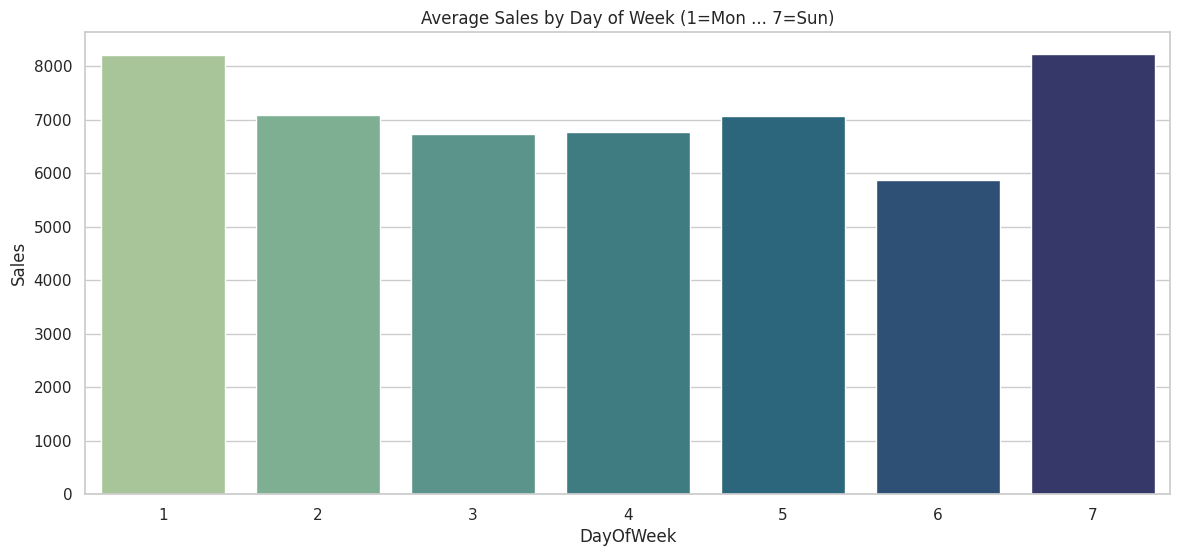

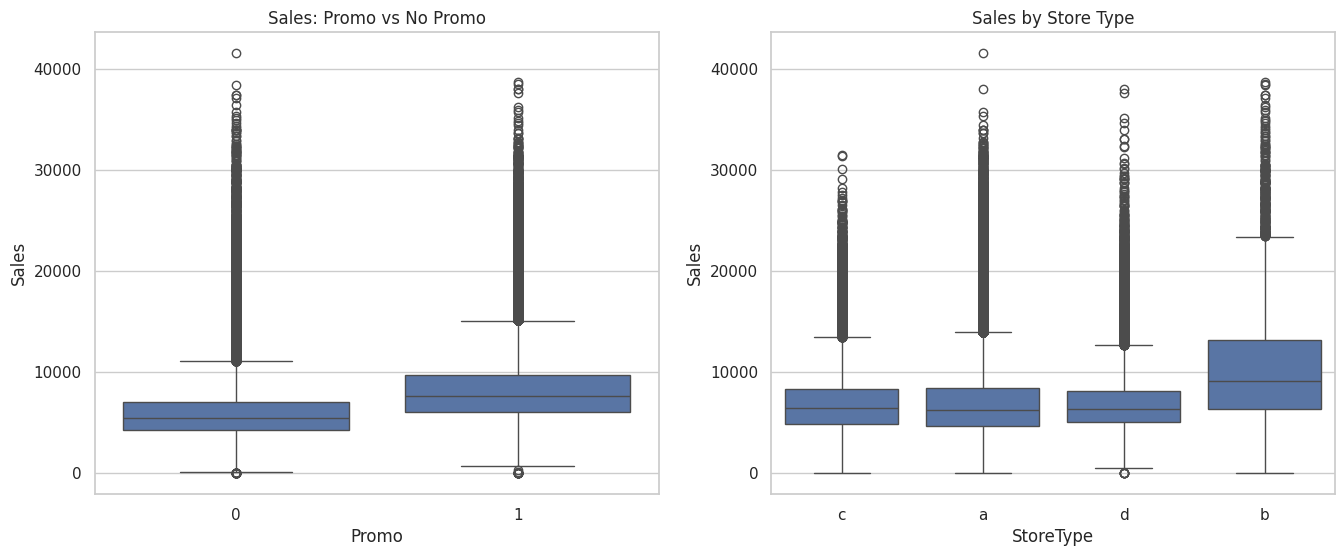

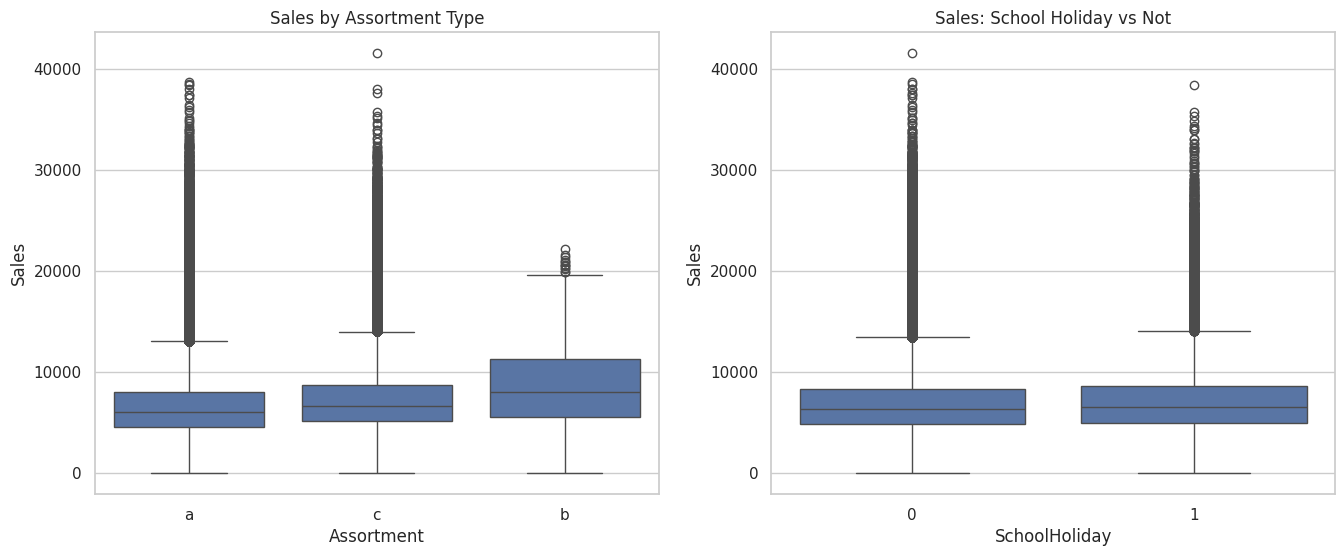

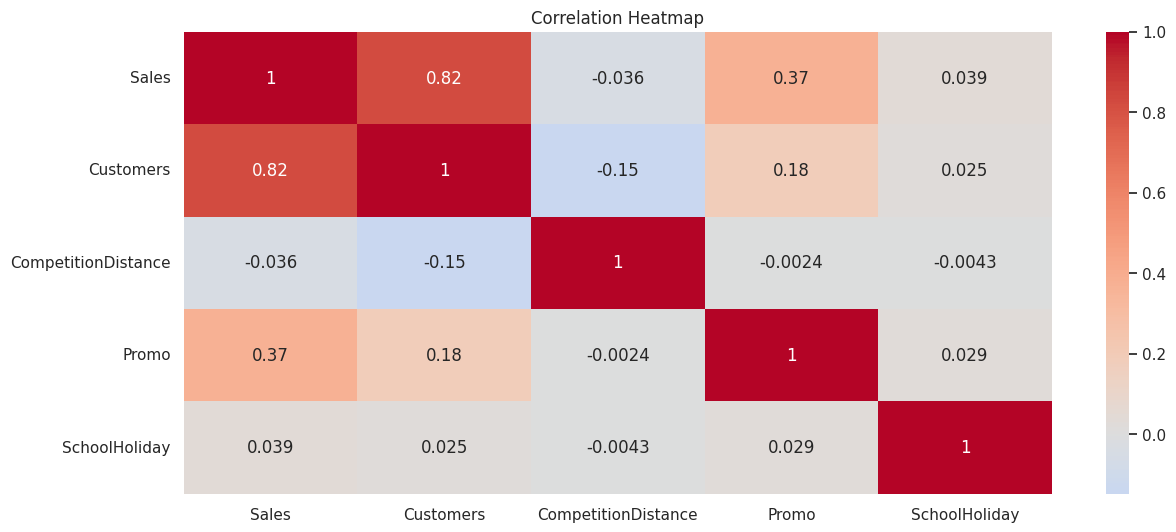

In [5]:
# 5. EDA — SEASONALITY, PROMOS, HOLIDAYS, STORE TYPES

dow_sales = train_open.groupby('DayOfWeek', as_index=False)['Sales'].mean()
ax = sns.barplot(data=dow_sales, x='DayOfWeek', y='Sales', hue='DayOfWeek', palette='crest', legend=False)
ax.set_title('Average Sales by Day of Week (1=Mon ... 7=Sun)')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=train_open, x='Promo', y='Sales', ax=axes[0])
axes[0].set_title('Sales: Promo vs No Promo')

sns.boxplot(data=train_open, x='StoreType', y='Sales', ax=axes[1])
axes[1].set_title('Sales by Store Type')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=train_open, x='Assortment', y='Sales', ax=axes[0])
axes[0].set_title('Sales by Assortment Type')

sns.boxplot(data=train_open, x='SchoolHoliday', y='Sales', ax=axes[1])
axes[1].set_title('Sales: School Holiday vs Not')
plt.show()

corr_cols = ['Sales', 'Customers', 'CompetitionDistance', 'Promo', 'SchoolHoliday']
corr = train_open[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

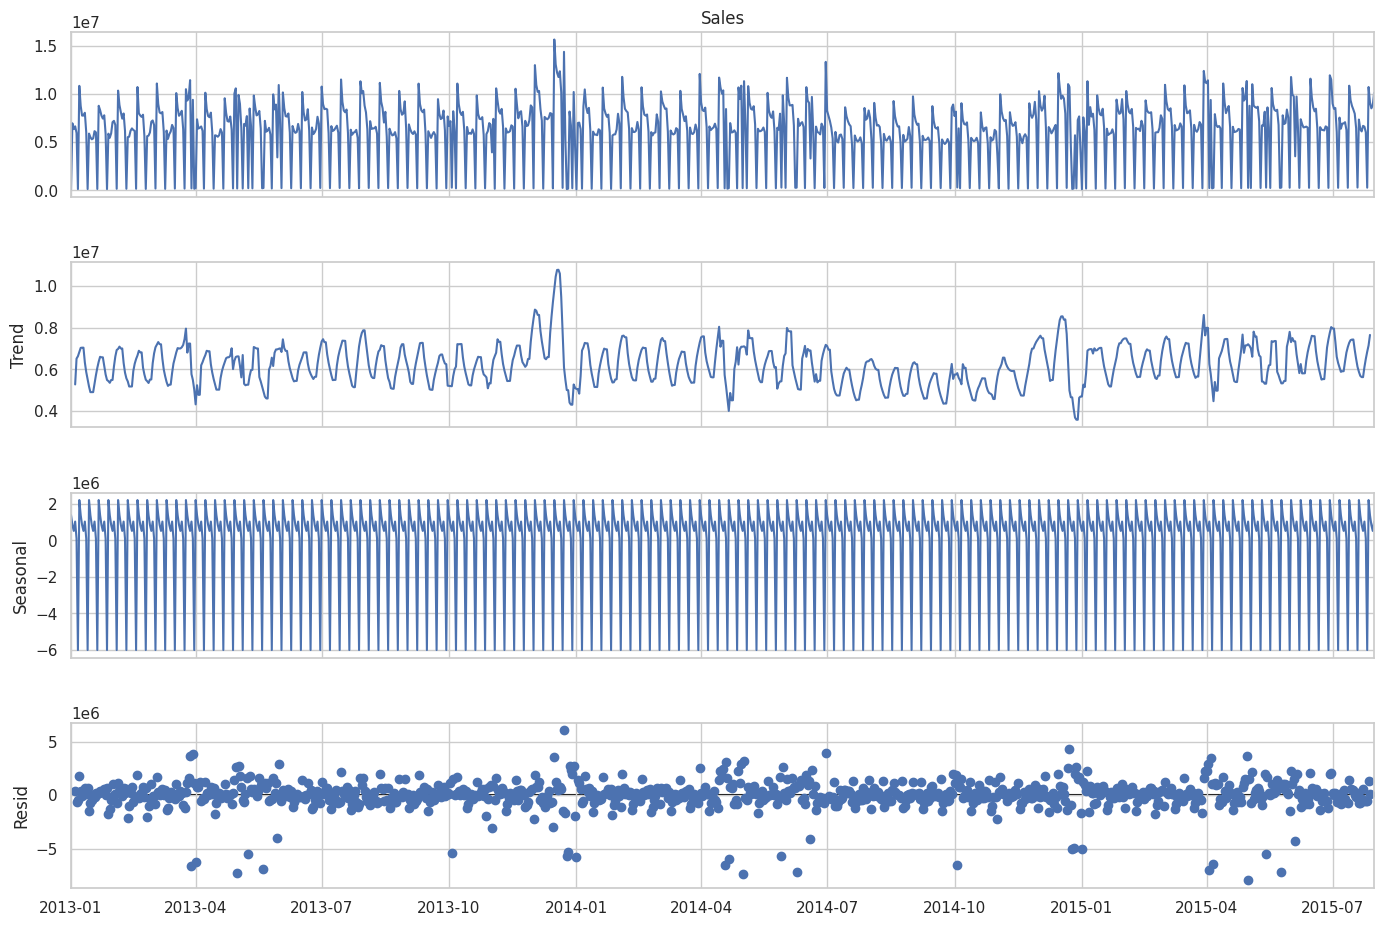

In [6]:
# 6. TREND & SEASONALITY DECOMPOSITION

ts = daily_sales.set_index('Date')['Sales'].asfreq('D').interpolate()
result = seasonal_decompose(ts, model='additive', period=7)

fig = result.plot()
fig.set_size_inches(14, 10)
plt.show()

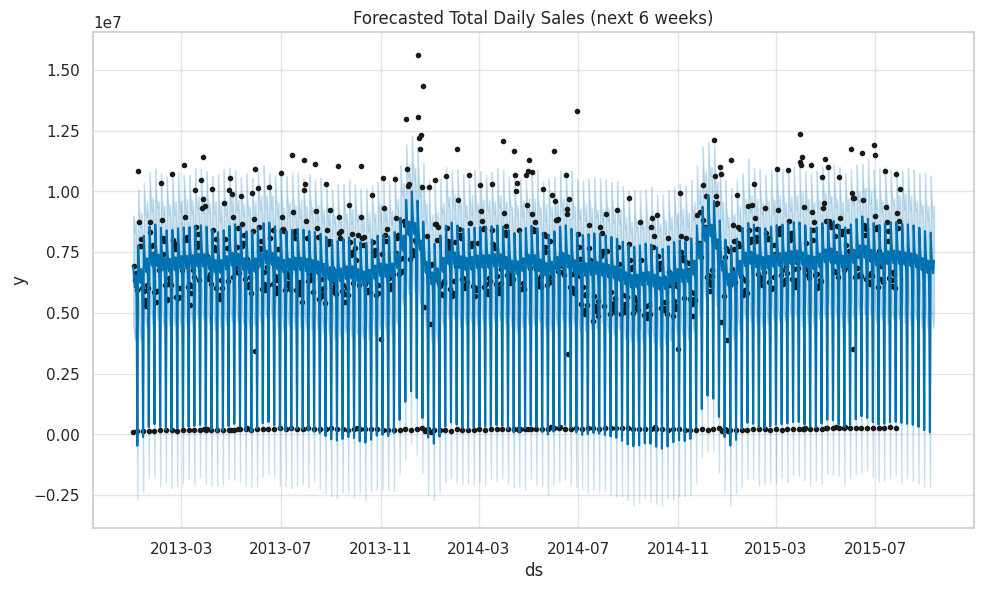

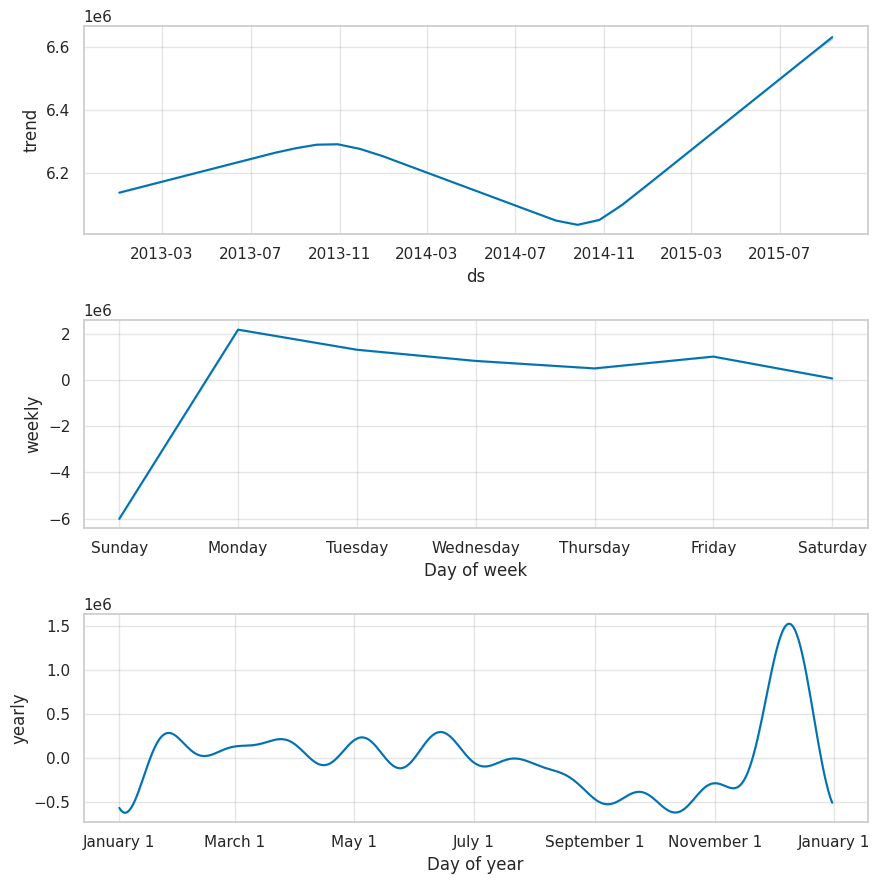

In [7]:
# 7. FORECASTING WITH PROPHET

from prophet import Prophet

prophet_df = daily_sales.rename(columns={'Date': 'ds', 'Sales': 'y'})

model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=42)  # 6 weeks ahead
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title('Forecasted Total Daily Sales (next 6 weeks)')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

MAE: 1,088,962
MAPE: 20.08%


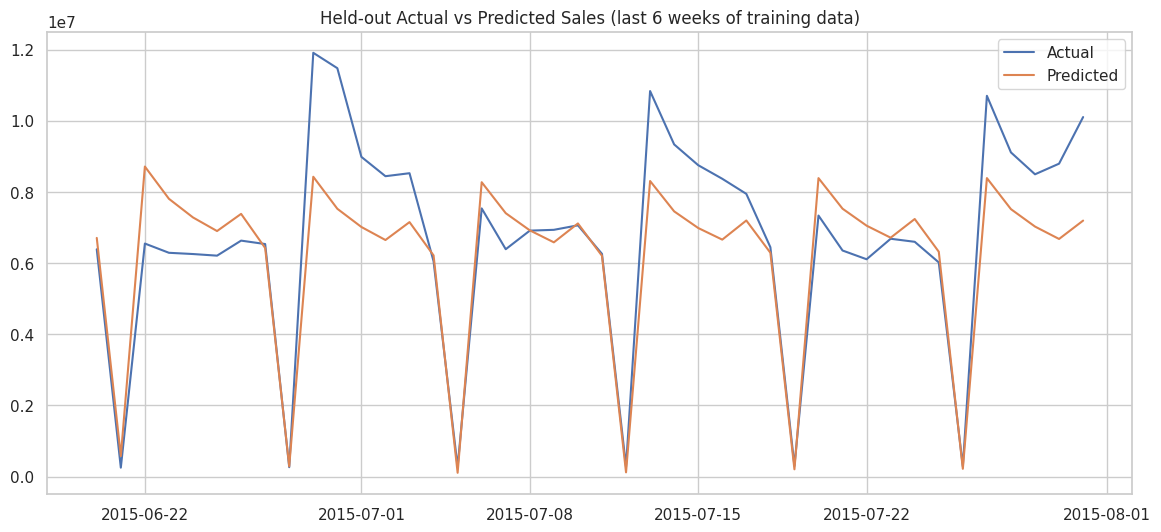

In [8]:
# 8. EVALUATING THE FORECAST

cutoff = prophet_df['ds'].max() - pd.Timedelta(days=42)
train_part = prophet_df[prophet_df['ds'] <= cutoff]
test_part = prophet_df[prophet_df['ds'] > cutoff]

eval_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
eval_model.fit(train_part)

eval_future = eval_model.make_future_dataframe(periods=len(test_part))
eval_forecast = eval_model.predict(eval_future)

comparison = test_part.merge(eval_forecast[['ds', 'yhat']], on='ds')
mae = (comparison['y'] - comparison['yhat']).abs().mean()
mape = ((comparison['y'] - comparison['yhat']).abs() / comparison['y']).mean() * 100

print(f'MAE: {mae:,.0f}')
print(f'MAPE: {mape:.2f}%')

plt.figure(figsize=(14,6))
plt.plot(comparison['ds'], comparison['y'], label='Actual')
plt.plot(comparison['ds'], comparison['yhat'], label='Predicted')
plt.legend()
plt.title('Held-out Actual vs Predicted Sales (last 6 weeks of training data)')
plt.show()